# Setup

In [2]:
import sys
import os
sys.path.append(os.path.abspath(os.path.join('..'))) # Adiciona a raiz do projeto ao path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from src.database import query_to_df

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

In [3]:
print("Loading data from database...\n")

prices_df = query_to_df("SELECT * FROM stock_prices ORDER BY ticker, date")
indicators_df = query_to_df("SELECT * FROM technical_indicators")
fundamentals_df = query_to_df("SELECT * FROM stock_fundamentals")
risk_df = query_to_df("SELECT * FROM risk_metrics")
signals_df = query_to_df("SELECT * FROM trading_signals")

print(f"Prices: {len(prices_df):,} rows")
print(f"Indicators: {len(indicators_df):,} rows")
print(f"Fundamentals: {len(fundamentals_df)} stocks")
print(f"Risk Metrics: {len(risk_df)} stocks")
print(f"Signals: {len(signals_df)} signals")

Loading data from database...

Prices: 10,000 rows
Indicators: 10,000 rows
Fundamentals: 20 stocks
Risk Metrics: 20 stocks
Signals: 21 signals


# Price Evolution (Análise de Tendência)

Plota a série temporal dos preços de fechamento para os 5 ativos com maior Sharpe Ratio.

Isso é útil para observar o comportamento histórico e a direção do preço. O SQL nos dá números pontuais, mas a visualização revela o **momentum**.

Interpretação:

* `Inclinação Positiva`: Indica uma tendência de alta no período.
* `Dispersão das Linhas`: Reflete a diferença de valor nominal entre os ativos (escalas de preço diferentes), não necessariamente uma performance superior de um sobre o outro sem normalização

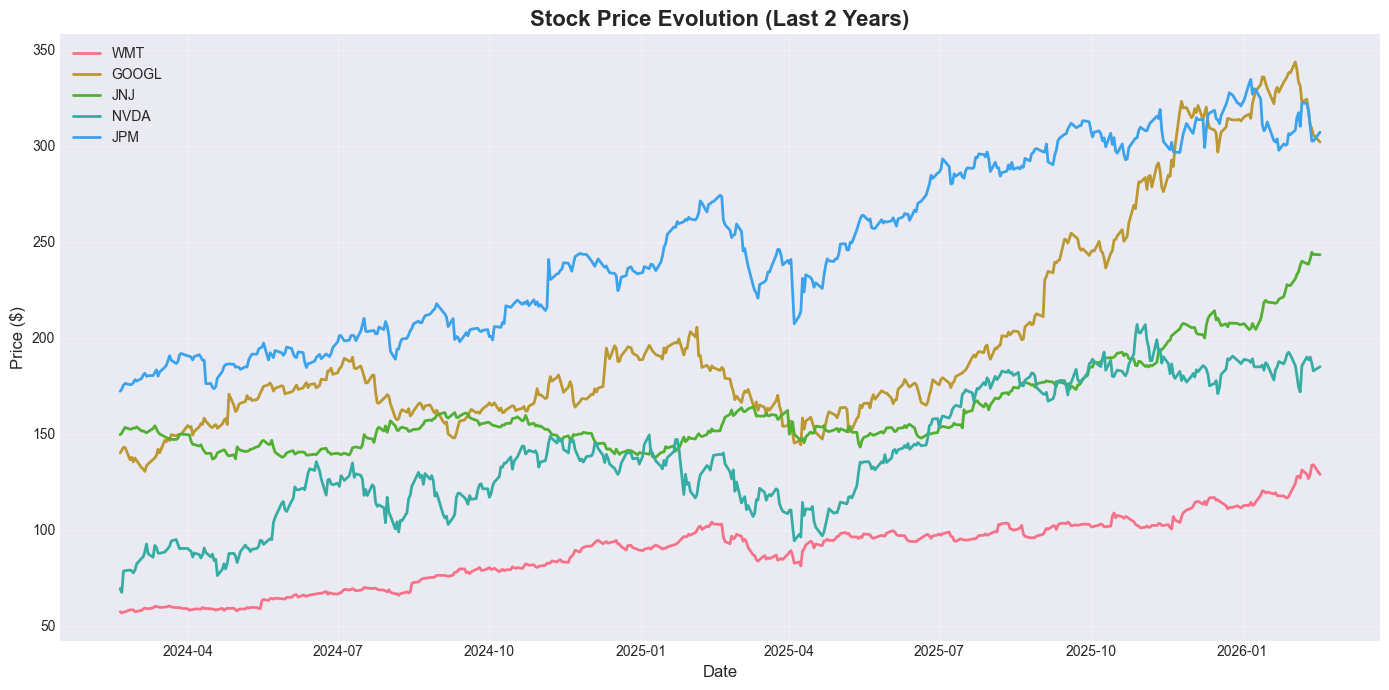

In [5]:
fig, ax = plt.subplots(figsize=(14, 7))

top_5_sharpe = risk_df.sort_values('sharpe_ratio', ascending=False)['ticker'].head(5).tolist()

for ticker in top_5_sharpe:
    stock_data = prices_df[prices_df['ticker'] == ticker]
    ax.plot(stock_data['date'], stock_data['close'], label=ticker, linewidth=2)

ax.set_title('Stock Price Evolution (Last 2 Years)', fontsize=16, fontweight='bold')
ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('Price ($)', fontsize=12)
ax.legend(loc='best')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Risk vs Return Scatter (Fronteira de Eficiência)

Mapeia os ativos em um plano cartesiano bidimensional: Volatilidade (Eixo X) e Retorno Anualizado (Eixo Y).

Isso é útil para identificar ativos que oferecem a melhor relação prêmio/risco.

Interpretação: 

* `Região Ideal (Superior Esquerda)`: Ativos com alto retorno e baixa volatilidade.
* `Gradiente de Cor (Sharpe)`: Quanto mais próximo do verde, melhor é a compensação de risco do ativo.

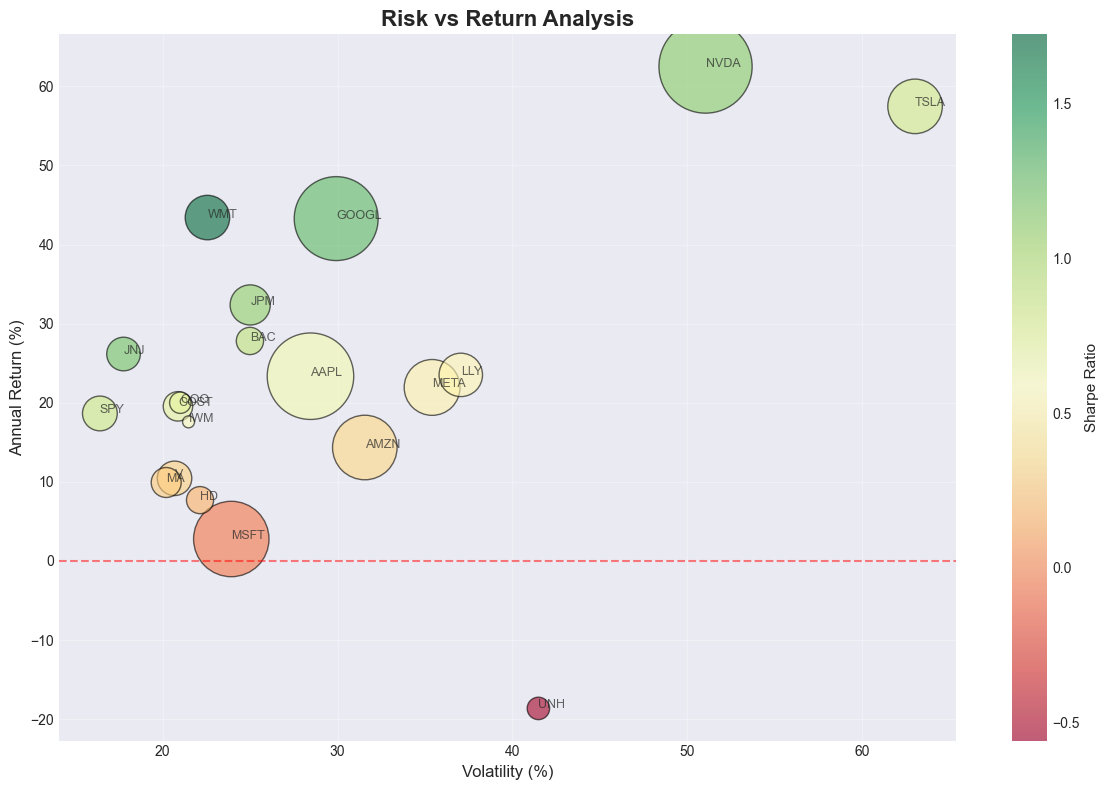

In [6]:
merged = fundamentals_df.merge(risk_df, on='ticker')

fig, ax = plt.subplots(figsize=(12, 8))
scatter = ax.scatter(
    merged['annualized_volatility'] * 100,
    merged['annualized_return'] * 100,
    s=merged['market_cap'] / 1e9,  # Size by market cap
    c=merged['sharpe_ratio'],      # Color by Sharpe
    cmap='RdYlGn',
    alpha=0.6,
    edgecolors='black',
    linewidth=1
)

# Annotate points
for _, row in merged.iterrows():
    ax.annotate(
        row['ticker'], 
        (row['annualized_volatility'] * 100, row['annualized_return'] * 100),
        fontsize=9,
        alpha=0.7
    )

ax.set_title('Risk vs Return Analysis', fontsize=16, fontweight='bold')
ax.set_xlabel('Volatility (%)', fontsize=12)
ax.set_ylabel('Annual Return (%)', fontsize=12)
ax.axhline(y=0, color='red', linestyle='--', alpha=0.5)
ax.grid(True, alpha=0.3)

cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('Sharpe Ratio', fontsize=11)
plt.tight_layout()
plt.show()

# Sector Performance (Agregação Setorial)

Consolida as métricas de performance (Sharpe Médio) agrupadas por setor econômico.

Foi feito para avaliar a **exposição setorial** e identificar quais segmentos da economia estão performando melhor sob a ótica de risco-retorno.

Interpretação: 
* Setores com barras mais longas indicam maior eficiência média das empresas que o compõem. Útil para decisões de rebalanceamento de carteira.


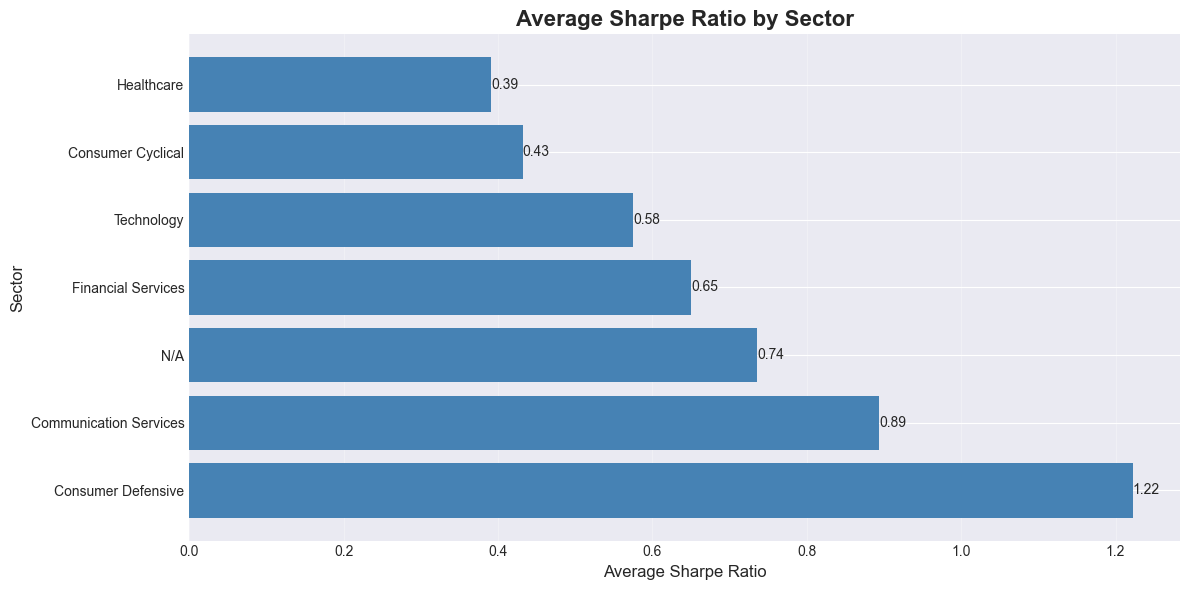

In [7]:
sector_performance = fundamentals_df.merge(risk_df, on='ticker')
sector_agg = sector_performance.groupby('sector').agg({
    'annualized_return': 'mean',
    'sharpe_ratio': 'mean',
    'ticker': 'count'
}).reset_index()
sector_agg.columns = ['sector', 'avg_return', 'avg_sharpe', 'num_stocks']
sector_agg = sector_agg.sort_values('avg_sharpe', ascending=False)

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.barh(sector_agg['sector'], sector_agg['avg_sharpe'], color='steelblue')
ax.set_title('Average Sharpe Ratio by Sector', fontsize=16, fontweight='bold')
ax.set_xlabel('Average Sharpe Ratio', fontsize=12)
ax.set_ylabel('Sector', fontsize=12)
ax.grid(axis='x', alpha=0.3)

# Add values on bars
for i, bar in enumerate(bars):
    width = bar.get_width()
    ax.text(width, bar.get_y() + bar.get_height()/2, 
            f'{width:.2f}', 
            ha='left', va='center', fontsize=10)

plt.tight_layout()
plt.show()

# Trading Signals Distribution (O Placar de Jogo)

Gera dois gráficos: um de barras horizontais contando a frequência de cada tipo de sinal (como RSI, Médias Móveis, etc.) e um gráfico de pizza mostrando a proporção da "força" desses sinais (Strong vs. Medium).

Feito para medir o sentimento do sistema. Enquanto os gráficos anteriores olham para o passado (preço e risco), esta célula olha para o presente: ela diz se o seu robô está detectando mais janelas de compra ou de venda agora.

Interpretação: 

* `Gráfico de Barras`: Identifica qual estratégia técnica está dominando o mercado. Se houver muitos sinais de Oversold (Sobrevenda), o mercado pode estar em um ponto de exaustão de queda e pronto para repicar.

* `Gráfico de Pizza`: Mede a convicção. Uma dominância de sinais Strong indica que os indicadores estão alinhados, aumentando a probabilidade estatística de acerto do sinal.

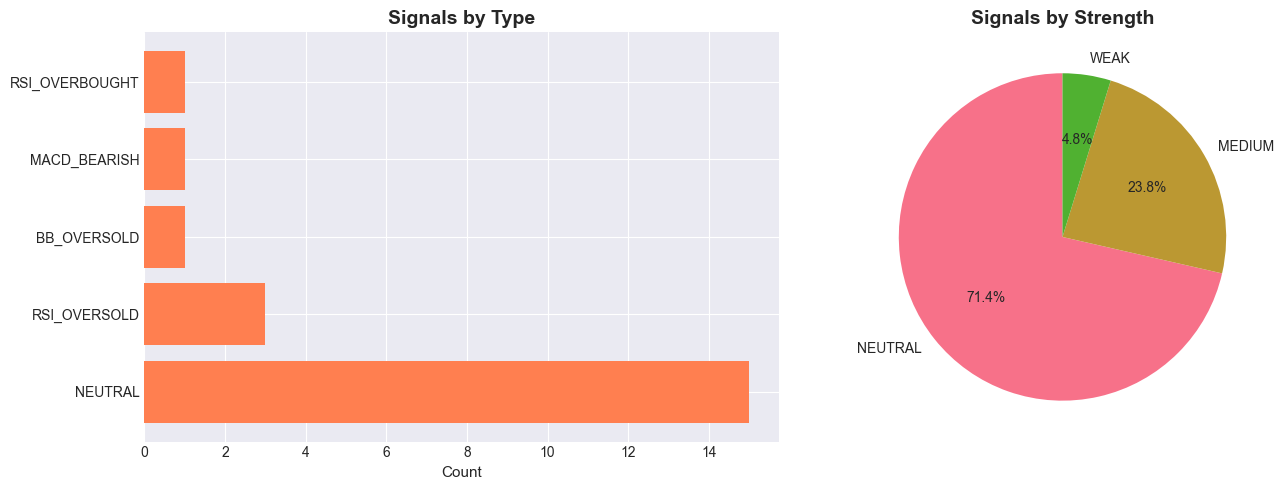

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Signal Type
signal_counts = signals_df['signal_type'].value_counts()
axes[0].barh(signal_counts.index, signal_counts.values, color='coral')
axes[0].set_title('Signals by Type', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Count', fontsize=11)

# Signal Strength
strength_counts = signals_df['signal_strength'].value_counts()
axes[1].pie(strength_counts.values, labels=strength_counts.index, autopct='%1.1f%%', startangle=90)
axes[1].set_title('Signals by Strength', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

# Summary Statistics (Relatório Executivo)
Consolida e imprime as principais métricas derivadas dos DataFrames: retorno médio anualizado, volatilidade média, Sharpe Ratio médio, além de indicadores fundamentalistas como P/E médio, Dividend Yield médio e o total de sinais de compra vs. venda gerados pelo sistema.

Isso está sendo feito para gerar um snapshot operacional do portfólio.
Em vez de analisar vários gráficos individualmente, essas estatísticas fornecem uma visão rápida do perfil geral de risco, retorno e valuation dos ativos analisados.

Esse tipo de resumo é comum em dashboards quantitativos e relatórios de gestão de portfólio, permitindo avaliar rapidamente se a carteira está alinhada com a estratégia de investimento.

Interpretação: 

**1. Best Sharpe**

Indica qual ativo apresentou o melhor retorno ajustado ao risco no período analisado.
É útil para identificar ativos que foram historicamente eficientes, mas não garante que continuarão performando melhor no futuro.

**2. Average P/E**

Representa o nível médio de valuation das empresas analisadas.
- P/E elevado: pode indicar expectativas altas de crescimento ou possível sobrevalorização.
- P/E baixo: pode sugerir ativos mais baratos ou empresas com menor expectativa de crescimento.

A interpretação ideal depende da média histórica do setor ou do mercado.

**3.Buy vs Sell Count**

Mostra o saldo de sinais gerados pelo sistema de trading.
Mais sinais de Buy: o modelo identifica mais oportunidades de entrada.
Mais sinais de Sell: o sistema sugere redução de exposição ou realização de lucros.
Esse indicador funciona como um termômetro quantitativo de momentum do mercado segundo as regras definidas no modelo.


In [16]:
print("=" * 60)
print("SUMMARY STATISTICS")
print("=" * 60 + "\n")

# =========================
# Risk Metrics
# =========================
avg_return = risk_df['annualized_return'].mean() * 100
avg_vol = risk_df['annualized_volatility'].mean() * 100
avg_sharpe = risk_df['sharpe_ratio'].mean()

best_idx = risk_df['sharpe_ratio'].idxmax()
best_sharpe = risk_df.loc[best_idx, 'sharpe_ratio']
best_ticker = risk_df.loc[best_idx, 'ticker']

print("Risk Metrics:")
print(f"Average Return: {avg_return:.2f}%")
print(f"Average Volatility: {avg_vol:.2f}%")
print(f"Average Sharpe Ratio: {avg_sharpe:.2f}")
print(f"Best Sharpe Ratio: {best_sharpe:.2f} ({best_ticker})")

# =========================
# Fundamental Metrics
# =========================
avg_pe = fundamentals_df['pe_ratio'].replace([float('inf'), -float('inf')], None).mean()

# Remove dividend yields absurdos (>50%) para evitar distorção
clean_div = fundamentals_df['dividend_yield']
clean_div = clean_div[(clean_div >= 0) & (clean_div <= 50)]

avg_dividend = clean_div.mean()

total_market_cap = fundamentals_df['market_cap'].sum() / 1e12

print("\nFundamental Metrics:")
print(f"Average P/E Ratio: {avg_pe:.2f}")
print(f"Average Dividend Yield: {avg_dividend:.2f}%")
print(f"Total Market Cap: ${total_market_cap:.2f}T")

# =========================
# Trading Signals
# =========================
total_signals = len(signals_df)

buy_signals = signals_df['signal_type'].str.contains(
    'BUY|BULLISH|OVERSOLD', case=False, na=False
).sum()

sell_signals = signals_df['signal_type'].str.contains(
    'SELL|BEARISH|OVERBOUGHT', case=False, na=False
).sum()

print("\nTrading Signals:")
print(f"Total Signals: {total_signals}")
print(f"Buy Signals: {buy_signals}")
print(f"Sell Signals: {sell_signals}")

print("=" * 60)

SUMMARY STATISTICS

Risk Metrics:
Average Return: 23.20%
Average Volatility: 28.75%
Average Sharpe Ratio: 0.66
Best Sharpe Ratio: 1.72 (WMT)

Fundamental Metrics:
Average P/E Ratio: 47.76
Average Dividend Yield: 1.08%
Total Market Cap: $27.23T

Trading Signals:
Total Signals: 21
Buy Signals: 4
Sell Signals: 2
